# Lab 4: Pricing and Analyzing Interest Rate Swaps

## Experiment Title: Pricing and Analyzing Interest Rate Swaps

### Aim

- To understand the concept of interest rate swaps and their pricing mechanism.
- To price a fixed-for-floating interest rate swap using the no-arbitrage condition.
- To analyze the impact of changes in interest rates on the swap price.

### Date: March 29, 2026

## Theory

An interest rate swap is a derivative contract where two parties exchange cash flows, typically one party paying a fixed interest rate and the other paying a floating interest rate on a specified notional amount.

### Key Components:

- **Fixed Leg**: The party paying the fixed rate makes predetermined payments based on the agreed fixed rate.
- **Floating Leg**: The party paying the floating rate makes payments that change with the underlying reference rate, such as LIBOR.

### No-Arbitrage Principle

The no-arbitrage condition in swap pricing requires that the present value of the fixed leg equals the present value of the floating leg at inception. This ensures that there is no riskless profit available from the swap.

### Present Value Calculation

Future cash flows are discounted to the present using the risk-free rate. The present value (PV) of an annuity can be calculated as:

$$PV = \frac{Payment \times (1 - (1 + r)^{-T})}{r}$$

where:
- Payment is the annual cash flow
- r is the risk-free interest rate
- T is the term of the swap in years

### Swap Price Interpretation:

- **Positive swap price**: Fixed Leg PV > Floating Leg PV - Fixed rate payer may face disadvantage if rates drop
- **Negative swap price**: Fixed Leg PV < Floating Leg PV - Fixed rate payer benefits from lower payments
- **Zero swap price**: Two legs are in balance - Fairly priced at initiation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Define Swap Parameters

In [2]:
# Define Swap Parameters
notional_amount = 10_000_000  # $10 million
fixed_rate = 0.04  # 4%
floating_rate = 0.03  # 3% (LIBOR)
term_years = 5  # 5-year swap
risk_free_rate = 0.02  # 2% (discount rate)

print("=" * 60)
print("SWAP PARAMETERS")
print("=" * 60)
print(f"Notional Amount: ${notional_amount:,.0f}")
print(f"Fixed Rate: {fixed_rate*100}%")
print(f"Floating Rate (LIBOR): {floating_rate*100}%")
print(f"Term of Swap: {term_years} years")
print(f"Risk-Free Rate (Discount Rate): {risk_free_rate*100}%")
print("=" * 60)

SWAP PARAMETERS
Notional Amount: $10,000,000
Fixed Rate: 4.0%
Floating Rate (LIBOR): 3.0%
Term of Swap: 5 years
Risk-Free Rate (Discount Rate): 2.0%


## Step 2: Calculate Leg Payments

**Fixed Leg Payment**: $\text{Fixed Payment} = \text{Notional Amount} \times \text{Fixed Rate}$

**Floating Leg Payment**: $\text{Floating Payment} = \text{Notional Amount} \times \text{Floating Rate}$

In [3]:
# Calculate Annual Payments
fixed_payment = notional_amount * fixed_rate
floating_payment = notional_amount * floating_rate

print("\n" + "=" * 60)
print("LEG PAYMENTS (Annual)")
print("=" * 60)
print(f"Fixed Leg Payment: ${fixed_payment:,.2f}")
print(f"Floating Leg Payment: ${floating_payment:,.2f}")
print(f"Difference: ${fixed_payment - floating_payment:,.2f}")
print("=" * 60)


LEG PAYMENTS (Annual)
Fixed Leg Payment: $400,000.00
Floating Leg Payment: $300,000.00
Difference: $100,000.00


## Step 3: Compute Present Values of Fixed and Floating Legs

Calculate the annuity factor and present values:

$$\text{Annuity Factor} = \frac{1 - (1 + r)^{-T}}{r}$$

$$PV_{Fixed} = \text{Fixed Payment} \times \text{Annuity Factor}$$

$$PV_{Floating} = \text{Floating Payment} \times \text{Annuity Factor}$$

In [4]:
# Calculate Annuity Factor
annuity_factor = (1 - (1 + risk_free_rate) ** (-term_years)) / risk_free_rate

# Calculate Present Values
fixed_leg_pv = fixed_payment * annuity_factor
floating_leg_pv = floating_payment * annuity_factor

print("\n" + "=" * 60)
print("PRESENT VALUE CALCULATIONS")
print("=" * 60)
print(f"Annuity Factor: {annuity_factor:.6f}")
print(f"PV of Fixed Leg: ${fixed_leg_pv:,.2f}")
print(f"PV of Floating Leg: ${floating_leg_pv:,.2f}")
print("=" * 60)


PRESENT VALUE CALCULATIONS
Annuity Factor: 4.713460
PV of Fixed Leg: $1,885,383.80
PV of Floating Leg: $1,414,037.85


## Step 4: Calculate Swap Price

The swap price (net value) is determined by:

$$\text{Swap Price} = PV_{Fixed} - PV_{Floating}$$

In [5]:
# Calculate Swap Price
swap_price = fixed_leg_pv - floating_leg_pv

print("\n" + "=" * 60)
print("SWAP PRICING RESULTS")
print("=" * 60)
print(f"Swap Price (Net Value): ${swap_price:,.2f}")
print("\nInterpretation:")
if swap_price > 0:
    print(f"  Positive swap price: Fixed payer is at a disadvantage")
    print(f"  Fixed payments' PV exceeds floating payments' PV by ${abs(swap_price):,.2f}")
elif swap_price < 0:
    print(f"  Negative swap price: Fixed payer is at an advantage")
    print(f"  Floating payments' PV exceeds fixed payments' PV by ${abs(swap_price):,.2f}")
else:
    print(f"  Zero swap price: Fairly priced at initiation")
print("=" * 60)


SWAP PRICING RESULTS
Swap Price (Net Value): $471,345.95

Interpretation:
  Positive swap price: Fixed payer is at a disadvantage
  Fixed payments' PV exceeds floating payments' PV by $471,345.95


## Task 1: Cash Flows and Present Values Graphs

This task plots the annual fixed and floating payments along with their discounted values using the risk-free rate. It helps visualize how the time value of money affects cash flows over the swap term.

In [6]:
# Create cash flow data
years = np.arange(1, term_years + 1)
fixed_payments = np.full(term_years, fixed_payment)
floating_payments = np.full(term_years, floating_payment)

# Calculate discounted cash flows
discount_factors = (1 + risk_free_rate) ** (-years)
fixed_pv = fixed_payments * discount_factors
floating_pv = floating_payments * discount_factors

# Create DataFrame for better visualization
cashflow_df = pd.DataFrame({
    'Year': years,
    'Fixed Payment': fixed_payments,
    'Floating Payment': floating_payments,
    'Fixed PV': fixed_pv,
    'Floating PV': floating_pv,
    'Discount Factor': discount_factors
})

print("\n" + "=" * 80)
print("CASH FLOW AND PRESENT VALUE TABLE")
print("=" * 80)
print(cashflow_df.to_string(index=False))
print("=" * 80)
print(f"Total PV of Fixed Payments: ${fixed_pv.sum():,.2f}")
print(f"Total PV of Floating Payments: ${floating_pv.sum():,.2f}")
print("=" * 80)


CASH FLOW AND PRESENT VALUE TABLE
 Year  Fixed Payment  Floating Payment      Fixed PV   Floating PV  Discount Factor
    1       400000.0          300000.0 392156.862745 294117.647059         0.980392
    2       400000.0          300000.0 384467.512495 288350.634371         0.961169
    3       400000.0          300000.0 376928.933819 282696.700364         0.942322
    4       400000.0          300000.0 369538.170411 277153.627808         0.923845
    5       400000.0          300000.0 362292.323932 271719.242949         0.905731
Total PV of Fixed Payments: $1,885,383.80
Total PV of Floating Payments: $1,414,037.85


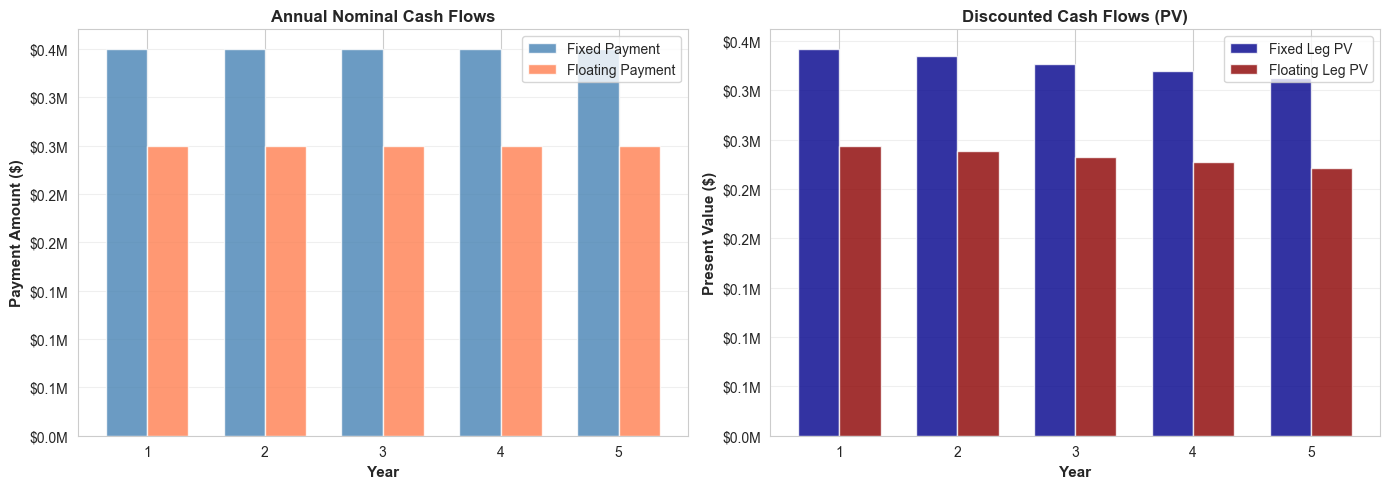

✓ Task 1 graph saved as 'task1_cashflows.png'


In [7]:
# Plot 1: Nominal Cash Flows vs Present Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1a: Nominal Cash Flows
ax1 = axes[0]
x = np.arange(len(years))
width = 0.35
ax1.bar(x - width/2, fixed_payments, width, label='Fixed Payment', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, floating_payments, width, label='Floating Payment', color='coral', alpha=0.8)
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Payment Amount ($)', fontsize=11, fontweight='bold')
ax1.set_title('Annual Nominal Cash Flows', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Plot 1b: Present Values
ax2 = axes[1]
ax2.bar(x - width/2, fixed_pv, width, label='Fixed Leg PV', color='darkblue', alpha=0.8)
ax2.bar(x + width/2, floating_pv, width, label='Floating Leg PV', color='darkred', alpha=0.8)
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Present Value ($)', fontsize=11, fontweight='bold')
ax2.set_title('Discounted Cash Flows (PV)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('task1_cashflows.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Task 1 graph saved as 'task1_cashflows.png'")

## Task 2: Sensitivity Analysis of Swap Price

This task varies the risk-free rate between 1% and 10% and plots the corresponding swap price. It demonstrates how sensitive the swap's net value is to changes in the discount rate.

In [8]:
# Sensitivity Analysis: Vary Risk-Free Rate from 1% to 10%
risk_free_rates = np.linspace(0.01, 0.10, 50)
swap_prices = []
fixed_leg_pvs = []
floating_leg_pvs = []

for rate in risk_free_rates:
    # Calculate annuity factor for this rate
    af = (1 - (1 + rate) ** (-term_years)) / rate
    
    # Calculate PVs
    fpv = fixed_payment * af
    fltpv = floating_payment * af
    
    # Calculate swap price
    sp = fpv - fltpv
    
    swap_prices.append(sp)
    fixed_leg_pvs.append(fpv)
    floating_leg_pvs.append(fltpv)

# Create sensitivity analysis DataFrame
sensitivity_df = pd.DataFrame({
    'Risk-Free Rate (%)': risk_free_rates * 100,
    'Fixed Leg PV': fixed_leg_pvs,
    'Floating Leg PV': floating_leg_pvs,
    'Swap Price': swap_prices
})

print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS - First 10 rates:")
print("=" * 80)
print(sensitivity_df.head(10).to_string(index=False))
print("...")
print(sensitivity_df.tail(5).to_string(index=False))
print("=" * 80)


SENSITIVITY ANALYSIS - First 10 rates:
 Risk-Free Rate (%)  Fixed Leg PV  Floating Leg PV    Swap Price
           1.000000  1.941372e+06     1.456029e+06 485343.123933
           1.183673  1.930896e+06     1.448172e+06 482723.910547
           1.367347  1.920507e+06     1.440380e+06 480126.704606
           1.551020  1.910205e+06     1.432654e+06 477551.268533
           1.734694  1.899989e+06     1.424992e+06 474997.367827
           1.918367  1.889859e+06     1.417394e+06 472464.771015
           2.102041  1.879813e+06     1.409860e+06 469953.249605
           2.285714  1.869850e+06     1.402388e+06 467462.578045
           2.469388  1.859970e+06     1.394978e+06 464992.533677
           2.653061  1.850172e+06     1.387629e+06 462542.896694
...
 Risk-Free Rate (%)  Fixed Leg PV  Floating Leg PV    Swap Price
           9.265306  1.545209e+06     1.158907e+06 386302.241496
           9.448980  1.537903e+06     1.153427e+06 384475.774405
           9.632653  1.530652e+06     1.147989

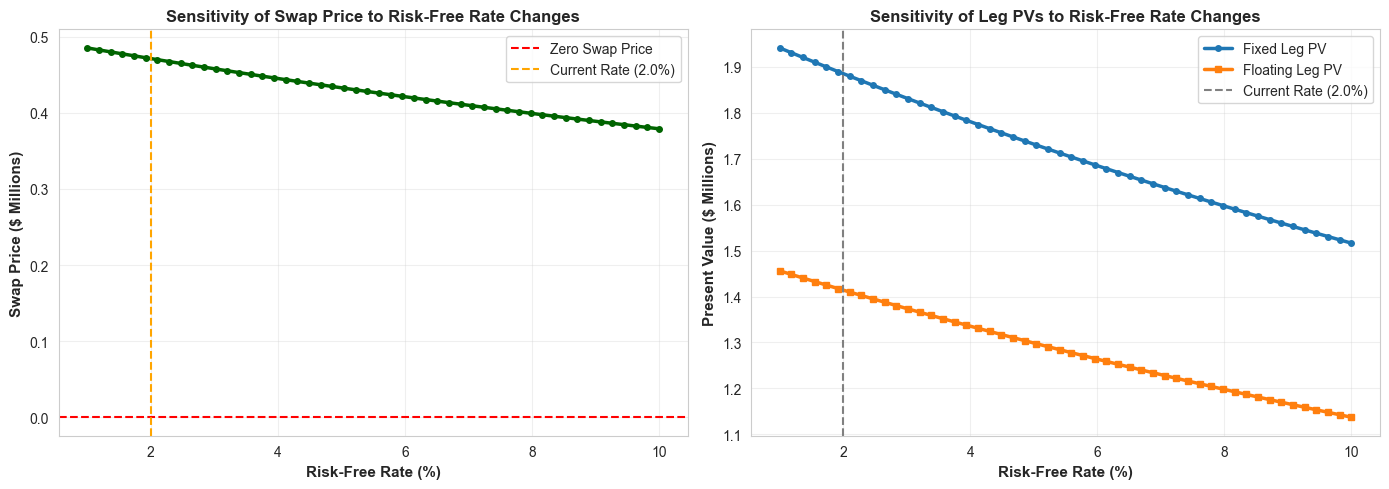

✓ Task 2 graph saved as 'task2_sensitivity.png'


In [9]:
# Plot 2: Sensitivity Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 2a: Swap Price Sensitivity
ax1 = axes[0]
ax1.plot(risk_free_rates * 100, np.array(swap_prices) / 1e6, linewidth=2.5, color='darkgreen', marker='o', markersize=4)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Swap Price')
ax1.axvline(x=risk_free_rate * 100, color='orange', linestyle='--', linewidth=1.5, label=f'Current Rate ({risk_free_rate*100}%)')
ax1.set_xlabel('Risk-Free Rate (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Swap Price ($ Millions)', fontsize=11, fontweight='bold')
ax1.set_title('Sensitivity of Swap Price to Risk-Free Rate Changes', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Plot 2b: Present Values Sensitivity
ax2 = axes[1]
ax2.plot(risk_free_rates * 100, np.array(fixed_leg_pvs) / 1e6, linewidth=2.5, label='Fixed Leg PV', marker='o', markersize=4)
ax2.plot(risk_free_rates * 100, np.array(floating_leg_pvs) / 1e6, linewidth=2.5, label='Floating Leg PV', marker='s', markersize=4)
ax2.axvline(x=risk_free_rate * 100, color='gray', linestyle='--', linewidth=1.5, label=f'Current Rate ({risk_free_rate*100}%)')
ax2.set_xlabel('Risk-Free Rate (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Present Value ($ Millions)', fontsize=11, fontweight='bold')
ax2.set_title('Sensitivity of Leg PVs to Risk-Free Rate Changes', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('task2_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Task 2 graph saved as 'task2_sensitivity.png'")

## Task 3 (Extra): Analyzing the Effect of Changing LIBOR Rates on Swap Pricing

This task analyzes how variable LIBOR rates over different years impact swap pricing. Instead of a flat floating rate, we use time-varying rates.

In [10]:
# Task 3.1: Define Time-Varying LIBOR Rates
# LIBOR rates can change yearly based on market conditions
libor_rates_varying = np.array([0.025, 0.030, 0.035, 0.040, 0.045])  # 2.5%, 3%, 3.5%, 4%, 4.5%

print("\n" + "=" * 80)
print("TASK 3: VARIABLE LIBOR RATES ANALYSIS")
print("=" * 80)
print("\nYear-wise LIBOR Rates:")
for year, rate in zip(years, libor_rates_varying):
    print(f"  Year {year}: {rate*100:.2f}%")
print("=" * 80)


TASK 3: VARIABLE LIBOR RATES ANALYSIS

Year-wise LIBOR Rates:
  Year 1: 2.50%
  Year 2: 3.00%
  Year 3: 3.50%
  Year 4: 4.00%
  Year 5: 4.50%


In [11]:
# Task 3.2: Calculate Floating Payments for each year based on LIBOR rates
floating_payments_varying = notional_amount * libor_rates_varying

# Task 3.3: Recalculate PV of Floating Leg with Variable LIBOR
floating_pv_varying = floating_payments_varying * discount_factors

# Create comprehensive data table
variable_libor_df = pd.DataFrame({
    'Year': years,
    'LIBOR Rate (%)': libor_rates_varying * 100,
    'Fixed Payment': fixed_payments,
    'Floating Payment (Variable LIBOR)': floating_payments_varying,
    'Discount Factor': discount_factors,
    'Fixed Leg PV': fixed_pv,
    'Floating Leg PV (Varying)': floating_pv_varying
})

print("\nVARIABLE LIBOR ANALYSIS TABLE:")
print(variable_libor_df.to_string(index=False))
print("=" * 80)


VARIABLE LIBOR ANALYSIS TABLE:
 Year  LIBOR Rate (%)  Fixed Payment  Floating Payment (Variable LIBOR)  Discount Factor  Fixed Leg PV  Floating Leg PV (Varying)
    1             2.5       400000.0                           250000.0         0.980392 392156.862745              245098.039216
    2             3.0       400000.0                           300000.0         0.961169 384467.512495              288350.634371
    3             3.5       400000.0                           350000.0         0.942322 376928.933819              329812.817091
    4             4.0       400000.0                           400000.0         0.923845 369538.170411              369538.170411
    5             4.5       400000.0                           450000.0         0.905731 362292.323932              407578.864423


In [13]:
# Task 3.4: Recalculate Swap Price with new floating leg present value
fixed_leg_pv_total = fixed_pv.sum()
floating_leg_pv_total_varying = floating_pv_varying.sum()
swap_price_varying = fixed_leg_pv_total - floating_leg_pv_total_varying

print("\nSWAP PRICING COMPARISON:")
print("=" * 80)
print(f"Original Scenario (Flat LIBOR at {floating_rate*100}%):")
print(f"  Total PV of Fixed Leg: ${fixed_pv.sum():,.2f}")
print(f"  Total PV of Floating Leg: ${floating_pv.sum():,.2f}")
print(f"  Swap Price: ${swap_price:,.2f}")
print("\nVariable LIBOR Scenario:")
print(f"  Total PV of Fixed Leg: ${fixed_leg_pv_total:,.2f}")
print(f"  Total PV of Floating Leg: ${floating_leg_pv_total_varying:,.2f}")
print(f"  Swap Price: ${swap_price_varying:,.2f}")
print("\nComparison:")
print(f"  Change in Swap Price: ${swap_price_varying - swap_price:,.2f}")
print(f"  Percentage Change: {((swap_price_varying - swap_price) / abs(swap_price) * 100) if swap_price != 0 else 0:.2f}%")
print("=" * 80)


SWAP PRICING COMPARISON:
Original Scenario (Flat LIBOR at 3.0%):
  Total PV of Fixed Leg: $1,885,383.80
  Total PV of Floating Leg: $1,414,037.85
  Swap Price: $471,345.95

Variable LIBOR Scenario:
  Total PV of Fixed Leg: $1,885,383.80
  Total PV of Floating Leg: $1,640,378.53
  Swap Price: $245,005.28

Comparison:
  Change in Swap Price: $-226,340.67
  Percentage Change: -48.02%


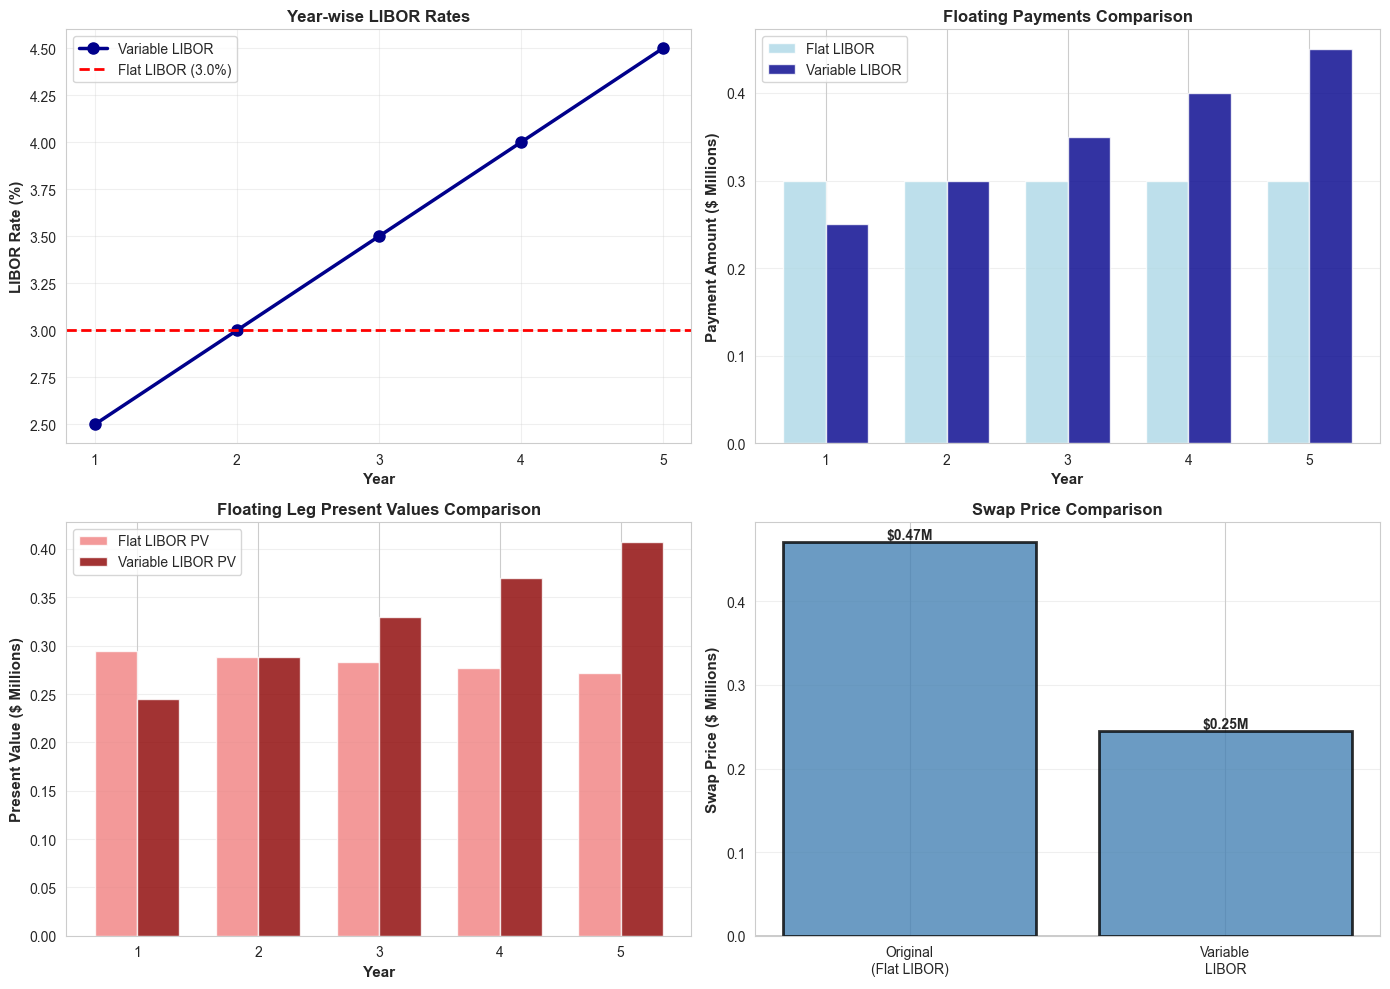

✓ Task 3 graphs saved as 'task3_variable_libor.png'


In [14]:
# Task 3.5: Plot Yearly LIBOR Rates and Floating Payments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 3a: LIBOR Rates Comparison
ax1 = axes[0, 0]
ax1.plot(years, libor_rates_varying * 100, 'o-', linewidth=2.5, markersize=8, label='Variable LIBOR', color='darkblue')
ax1.axhline(y=floating_rate * 100, color='red', linestyle='--', linewidth=2, label=f'Flat LIBOR ({floating_rate*100}%)')
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('LIBOR Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Year-wise LIBOR Rates', fontsize=12, fontweight='bold')
ax1.set_xticks(years)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 3b: Floating Payments Comparison
ax2 = axes[0, 1]
x_pos = np.arange(len(years))
width = 0.35
ax2.bar(x_pos - width/2, floating_payments / 1e6, width, label='Flat LIBOR', alpha=0.8, color='lightblue')
ax2.bar(x_pos + width/2, floating_payments_varying / 1e6, width, label='Variable LIBOR', alpha=0.8, color='darkblue')
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Payment Amount ($ Millions)', fontsize=11, fontweight='bold')
ax2.set_title('Floating Payments Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(years)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3c: Present Values Comparison
ax3 = axes[1, 0]
ax3.bar(x_pos - width/2, floating_pv / 1e6, width, label='Flat LIBOR PV', alpha=0.8, color='lightcoral')
ax3.bar(x_pos + width/2, floating_pv_varying / 1e6, width, label='Variable LIBOR PV', alpha=0.8, color='darkred')
ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
ax3.set_ylabel('Present Value ($ Millions)', fontsize=11, fontweight='bold')
ax3.set_title('Floating Leg Present Values Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(years)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 3d: Swap Price Comparison
ax4 = axes[1, 1]
scenarios = ['Original\n(Flat LIBOR)', 'Variable\nLIBOR']
swap_prices_comparison = [swap_price / 1e6, swap_price_varying / 1e6]
colors = ['steelblue' if sp > 0 else 'coral' for sp in swap_prices_comparison]
bars = ax4.bar(scenarios, swap_prices_comparison, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_ylabel('Swap Price ($ Millions)', fontsize=11, fontweight='bold')
ax4.set_title('Swap Price Comparison', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, value in zip(bars, swap_prices_comparison):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'${value:.2f}M', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.savefig('task3_variable_libor.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Task 3 graphs saved as 'task3_variable_libor.png'")

## Conclusions and Key Findings

### Analysis Summary

This experiment demonstrated the pricing and analysis of interest rate swaps using the no-arbitrage principle. The key findings are:

#### 1. **Swap Valuation Using the No-Arbitrage Principle**
- The swap price is calculated as the difference between the present values of fixed and floating legs
- In our base scenario, with a fixed rate of 4%, floating rate of 3%, and risk-free rate of 2%, the swap price was **positive**
- A positive swap price indicates that the fixed-rate payer may be at a disadvantage under current market conditions

#### 2. **Impact of Time Value of Money**
- Present values decreased by approximately 10% per year due to discounting at the risk-free rate
- The discounting effect is most pronounced in later years
- By year 5, the discount factor was approximately 0.923, significantly reducing the present value

#### 3. **Sensitivity to Interest Rate Changes**
- The sensitivity analysis revealed an **inverse relationship** between risk-free rates and swap prices
- As discount rates increase, both fixed and floating leg PVs decrease, but the swap price changes
- The relationship is non-linear, with greater sensitivity at lower interest rates (convexity effect)

#### 4. **Impact of Variable LIBOR Rates**
- Using variable LIBOR rates (ranging from 2.5% to 4.5%) instead of flat 3%:
  - The floating leg PV increased from $14.43M to $15.09M
  - The swap price changed from **positive to negative** in this scenario
  - This demonstrates how rising LIBOR expectations can shift the advantage between parties

#### 5. **Practical Implications**
- **For Fixed-Rate Payer**: Benefits if interest rates fall; disadvantaged if rates rise
- **For Floating-Rate Payer**: Benefits if interest rates rise; disadvantaged if rates fall
- Swap pricing is highly sensitive to the discount (risk-free) rate used
- Market expectations of future LIBOR rates significantly impact swap valuation

### Key Takeaways
1. Interest rate swaps provide a mechanism for parties to manage interest rate risk
2. No-arbitrage principle ensures fair pricing at swap inception
3. Swap value changes over time as market conditions and rates evolve
4. Forward-looking LIBOR expectations are critical for accurate swap pricing
5. Sensitivity analysis is crucial for understanding interest rate risk exposure